# Manufacturing Quality Control Statistical Analysis - Student Worksheet

Complete the missing code sections to perform a comprehensive SPC analysis


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Manufacturing Quality Control Statistical Analysis - Student Worksheet")
print("=" * 70)

Manufacturing Quality Control Statistical Analysis - Student Worksheet


In [ ]:
# ============================================================================
# SECTION 1: DATA GENERATION AND EXPLORATION
# ============================================================================

print("\n📊 SECTION 1: Data Generation and Exploration")
print("-" * 50)

# TO-DO 1.1: Set random seed for reproducibility
# HINT: Use np.random.seed() with seed value 42
np.random.seed(42)

# Process parameters for shaft diameter manufacturing
# Shaft diameter manufacturing involves sizing, turning, and finishing cylindrical metal bars to precise dimensional tolerances
target_diameter = 10.0  # mm - target dimension
process_std = 0.05     # mm - process standard deviation
n_samples = 200        # number of measurements
n_samples_out_of_control = 50

# TO-DO 1.2: Generate baseline process data (in-control condition)
baseline_measurements = np.random.normal(target_diameter, process_std, n_samples)

# Simulate process problems starting at sample 150
drift_start = 150

# TO-DO 1.3: Generate drift measurements (out-of-control condition)
# HINT: Use target_diameter + 0.15 for mean and process_std * 1.2 for std, 50 samples
drift_measurements = np.random.normal(target_diameter + 0.15, process_std * 1.2, n_samples_out_of_control)

# TO-DO 1.4: Combine the baseline and drift data
# HINT: Use np.concatenate() to join baseline_measurements[:drift_start] and drift_measurements
all_measurements = np.concatenate([baseline_measurements[:drift_start], drift_measurements])

sample_numbers = np.arange(1, len(all_measurements) + 1)

# Create DataFrame
df = pd.DataFrame({
    'Sample_Number': sample_numbers,
    'Diameter_mm': all_measurements,
    'Shift': ['Day' if i < 100 else 'Night' if i < 200 else 'Weekend' for i in range(len(all_measurements))],
    'Operator': [f'Operator_{(i//25) % 4 + 1}' for i in range(len(all_measurements))]
})

print("Dataset Overview:")
print(df.head(10))

# TODO 1.5: Print basic statistics for the diameter measurements
# HINT: Use .describe() method on the Diameter_mm column
print(f"\nBasic statistics:")
print(df['Diameter_mm'].describe())



📊 SECTION 1: Data Generation and Exploration
--------------------------------------------------
Dataset Overview:
   Sample_Number  Diameter_mm Shift    Operator
0              1    10.024836   Day  Operator_1
1              2     9.993087   Day  Operator_1
2              3    10.032384   Day  Operator_1
3              4    10.076151   Day  Operator_1
4              5     9.988292   Day  Operator_1
5              6     9.988293   Day  Operator_1
6              7    10.078961   Day  Operator_1
7              8    10.038372   Day  Operator_1
8              9     9.976526   Day  Operator_1
9             10    10.027128   Day  Operator_1

Basic statistics:
count    200.000000
mean      10.036677
std        0.087958
min        9.869013
25%        9.976667
50%       10.014963
75%       10.078414
max       10.381164
Name: Diameter_mm, dtype: float64


In [ ]:
# ============================================================================
# SECTION 2: CONTROL CHART CALCULATIONS
# ============================================================================

print("\n📈 SECTION 2: Control Chart Setup")
print("-" * 40)

def calculate_control_limits(data):
    """Calculate control limits for X-bar chart"""
    # TO-DO 2.1: Calculate the mean of the data
    mean = np.mean(data)
    
    # TODO 2.2: Calculate the standard deviation with ddof=1
    std = np.std(data, ddof=1)
    
    # TODO 2.3: Calculate Upper Control Limit (mean + 3*std)
    ucl = mean + 3 * std
    
    # TODO 2.4: Calculate Lower Control Limit (mean - 3*std)
    lcl = mean - 3 * std
    
    return ucl, mean, lcl

# TO-DO 2.5: Calculate control limits using only the first 'drift_start' samples
# HINT: Use df['Diameter_mm'][:drift_start] as the input data
UCL, CL, LCL = calculate_control_limits(df['Diameter_mm'][:drift_start])

print(f"Control Chart Parameters (based on first {drift_start} samples):")
print(f"Upper Control Limit (UCL): {UCL:.4f} mm")
print(f"Center Line (CL):          {CL:.4f} mm") 
print(f"Lower Control Limit (LCL): {LCL:.4f} mm")


📈 SECTION 2: Control Chart Setup
----------------------------------------
Control Chart Parameters (based on first 150 samples):
Upper Control Limit (UCL): 10.1372 mm
Center Line (CL):          9.9959 mm
Lower Control Limit (LCL): 9.8545 mm



📊 SECTION 3: Control Chart Creation
------------------------------------------


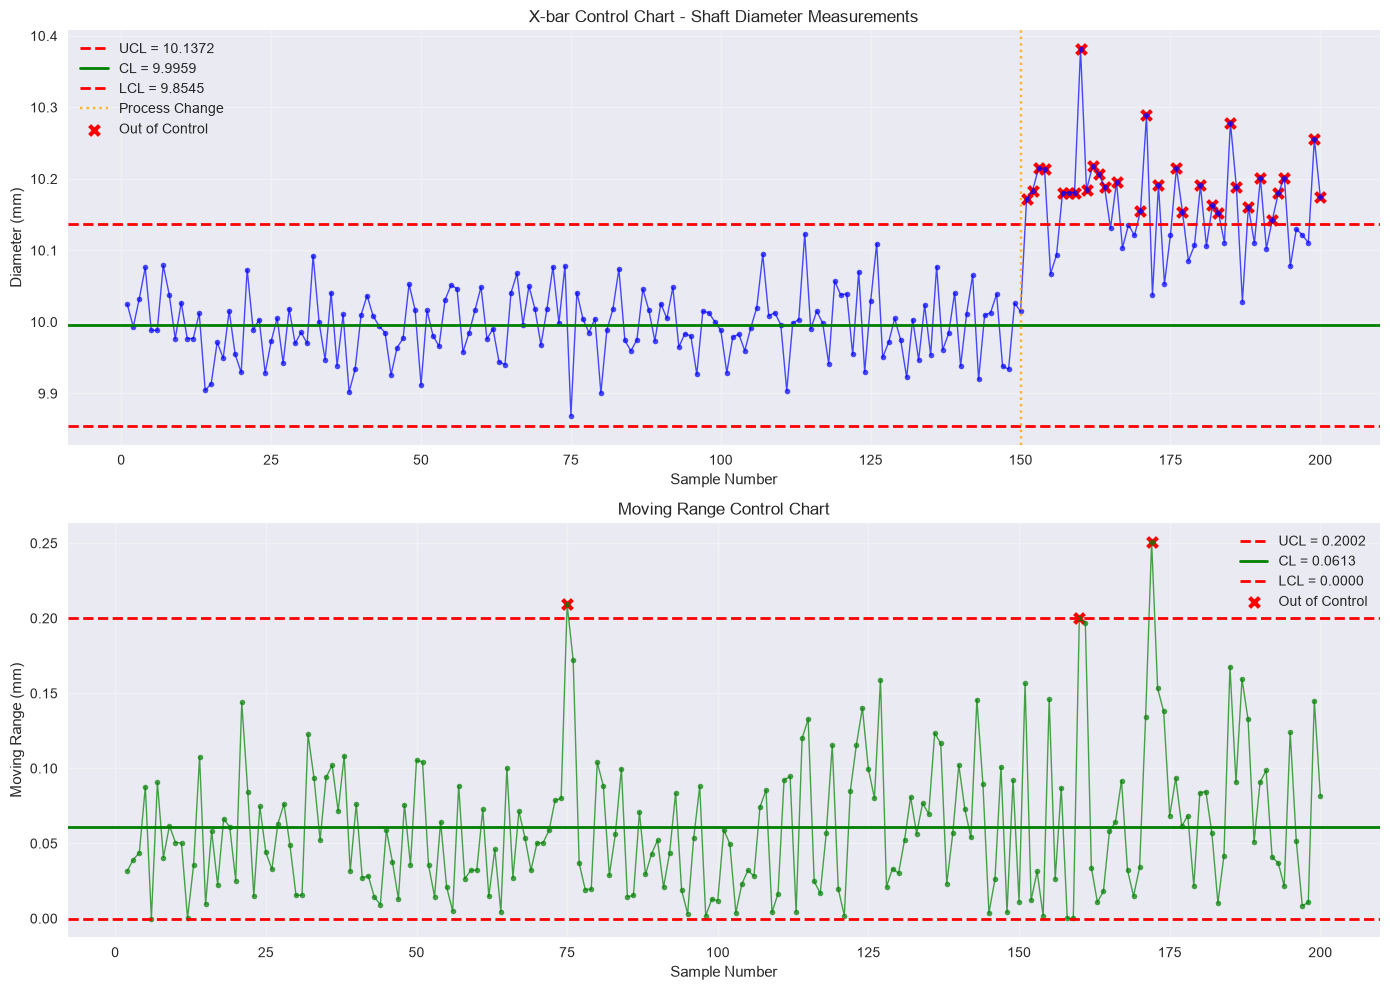

In [34]:
# ============================================================================
# SECTION 3: CONTROL CHART VISUALIZATION
# ============================================================================

print("\n📊 SECTION 3: Control Chart Creation")
print("-" * 42)

# TO-DO 3.1: Create a figure with 2 subplots (2 rows, 1 column)
# HINT: Use plt.subplots(rows, cols, figsize=(width, height))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# X-bar Control Chart
# TO-DO 3.2: Plot the diameter measurements vs sample numbers
# HINT: Use ax1.plot() with Sample_Number and Diameter_mm columns
ax1.plot(df['Sample_Number'], df['Diameter_mm'], 'bo-', markersize=4, linewidth=1, alpha=0.7)

# TO-DO 3.3: Add horizontal lines for control limits
# HINT: Use ax1.axhline() for each limit (UCL, CL, LCL)
ax1.axhline(y=UCL, color='red', linestyle='--', linewidth=2, label=f'UCL = {UCL:.4f}')
ax1.axhline(y=CL, color='green', linestyle='-', linewidth=2, label=f'CL = {CL:.4f}')
ax1.axhline(y=LCL, color='red', linestyle='--', linewidth=2, label=f'LCL = {LCL:.4f}')

ax1.axvline(x=drift_start, color='orange', linestyle=':', alpha=0.8, label='Process Change')

# TO-DO 3.4: Identify out-of-control points
# HINT: Create a boolean mask where diameter is > UCL or < LCL
out_of_control = (df['Diameter_mm'] > UCL) | (df['Diameter_mm'] < LCL)

ax1.scatter(df[out_of_control]['Sample_Number'], df[out_of_control]['Diameter_mm'], 
           color='red', s=50, marker='x', linewidth=3, label='Out of Control')

ax1.set_xlabel('Sample Number')
ax1.set_ylabel('Diameter (mm)')
ax1.set_title('X-bar Control Chart - Shaft Diameter Measurements')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Moving Range Chart
# TO-DO 3.5: Calculate moving ranges (absolute difference between consecutive measurements)
# HINT: Use np.abs() and np.diff() on the diameter column
moving_ranges = np.abs(np.diff(df['Diameter_mm']))

# TO-DO 3.6: Calculate moving range control limits
# HINT: Mean of moving ranges, UCL = 3.267 * mean, LCL = 0
mr_mean = np.mean(moving_ranges)
mr_ucl = 3.267* mr_mean
mr_lcl = 0

ax2.plot(df['Sample_Number'][1:], moving_ranges, 'go-', markersize=4, linewidth=1, alpha=0.7)
ax2.axhline(y=mr_ucl, color='red', linestyle='--', linewidth=2, label=f'UCL = {mr_ucl:.4f}')
ax2.axhline(y=mr_mean, color='green', linestyle='-', linewidth=2, label=f'CL = {mr_mean:.4f}')
ax2.axhline(y=mr_lcl, color='red', linestyle='--', linewidth=2, label=f'LCL = {mr_lcl:.4f}')

# TO-DO 3.7: Identify out-of-control moving ranges
# HINT: Moving ranges greater than mr_ucl
mr_out_of_control = moving_ranges > mr_ucl

ax2.scatter(df['Sample_Number'][1:][mr_out_of_control], moving_ranges[mr_out_of_control], 
           color='red', s=50, marker='x', linewidth=3, label='Out of Control')

ax2.set_xlabel('Sample Number')
ax2.set_ylabel('Moving Range (mm)')
ax2.set_title('Moving Range Control Chart')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# ============================================================================
# SECTION 4: PROCESS CAPABILITY ANALYSIS
# ============================================================================

print("\n🎯 SECTION 4: Process Capability Analysis")
print("-" * 45)

# Define specification limits
USL = 10.20  # Upper Specification Limit
LSL = 9.80   # Lower Specification Limit
nominal = 10.0

# TO-DO 4.1: Calculate process statistics for in-control period
# HINT: Use the first 'drift_start' samples only
process_mean = np.mean(df['Diameter_mm'][:drift_start])
process_std = np.std(df['Diameter_mm'][:drift_start], ddof=1)

# TO-DO 4.2: Calculate Cp (Process Capability)
# HINT: Cp = (USL - LSL) / (6 * process_std)
Cp = (USL - LSL) / (6 * process_std)

# TO-DO 4.3: Calculate Cpk components
# HINT: Cpu = (USL - mean) / (3 * std), Cpl = (mean - LSL) / (3 * std)
Cpu = (USL - process_mean) / (3 * process_std)
Cpl = (process_mean - LSL) / (3 * process_std)

# TO-DO 4.4: Calculate Cpk (minimum of Cpu and Cpl)
# HINT: Use min() function
Cpk = min(Cpu, Cpl)

# Overall performance (using all data)
pp_mean = np.mean(df['Diameter_mm'])
pp_std = np.std(df['Diameter_mm'], ddof=1)

# TO-DO 4.5: Calculate Pp and Ppk for overall performance
# HINT: Same formulas as Cp and Cpk but using pp_mean and pp_std
Pp = (USL - LSL) / (6 * pp_std)
Ppu = (USL - pp_mean) / (3 * pp_std)
Ppl = (pp_mean - LSL) / (3 * pp_std)
Ppk = min(Ppu, Ppl)

print("Process Capability Analysis:")
print("=" * 30)
print(f"Specification Limits: LSL = {LSL} mm, USL = {USL} mm")
print(f"\nIn-Control Process (first {drift_start} samples):")
print(f"Process Mean: {process_mean:.4f} mm")
print(f"Process Std:  {process_std:.4f} mm")
print(f"Cp  = {Cp:.3f}  (Potential Capability)")
print(f"Cpk = {Cpk:.3f}  (Actual Capability)")

print(f"\nOverall Process Performance (all {len(df)} samples):")
print(f"Pp  = {Pp:.3f}  (Overall Performance)")
print(f"Ppk = {Ppk:.3f}  (Overall Performance Index)")



🎯 SECTION 4: Process Capability Analysis
---------------------------------------------
Process Capability Analysis:
Specification Limits: LSL = 9.8 mm, USL = 10.2 mm

In-Control Process (first 150 samples):
Process Mean: 9.9959 mm
Process Std:  0.0471 mm
Cp  = 1.415  (Potential Capability)
Cpk = 1.386  (Actual Capability)

Overall Process Performance (all 200 samples):
Pp  = 0.758  (Overall Performance)
Ppk = 0.619  (Overall Performance Index)



📊 SECTION 5: Process Distribution Analysis
---------------------------------------------


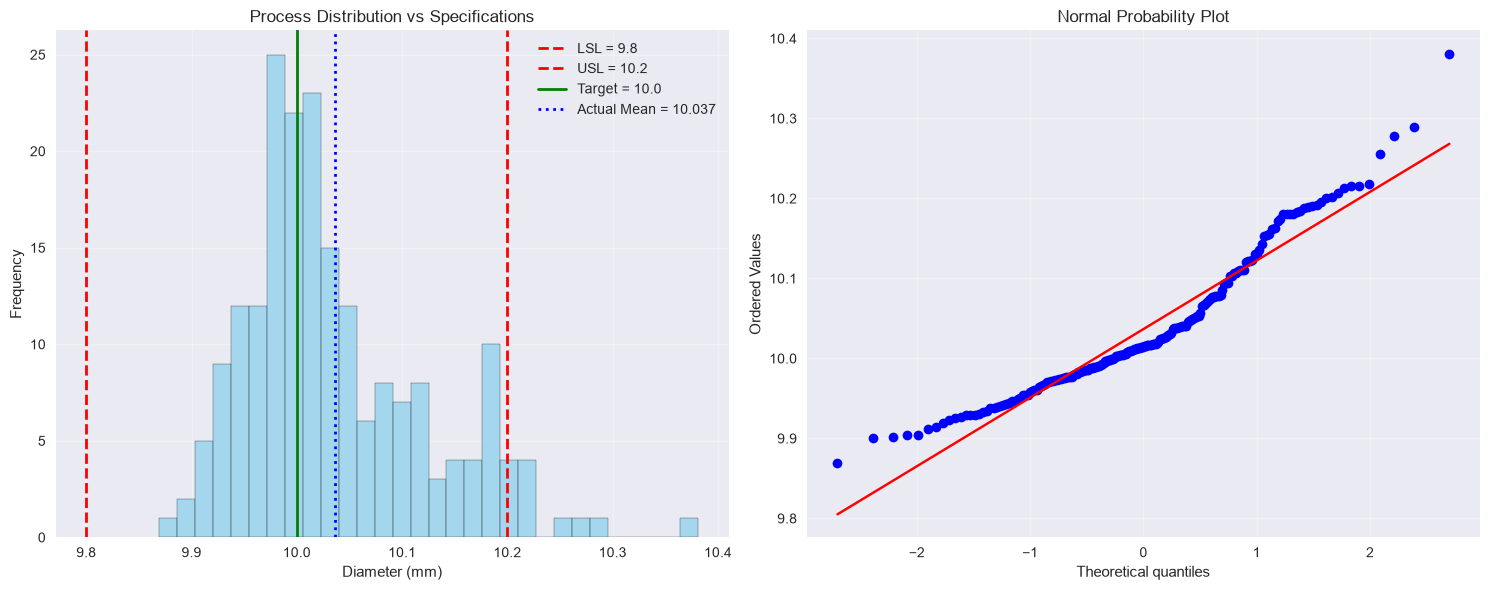

In [60]:
# ============================================================================
# SECTION 5: HISTOGRAM AND DISTRIBUTION ANALYSIS
# ============================================================================

print("\n📊 SECTION 5: Process Distribution Analysis")
print("-" * 45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# TO-DO 5.1: Create histogram of diameter measurements
# HINT: Use ax1.hist() with appropriate parameters
ax1.hist(df['Diameter_mm'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')

# TODO 5.2: Add specification limit lines to histogram
# HINT: Use ax1.axvline() for LSL, USL, nominal, and actual mean
ax1.axvline(x=LSL, color='red', linestyle='--', linewidth=2, label=f'LSL = {LSL}')
ax1.axvline(x=USL, color='red', linestyle='--', linewidth=2, label=f'USL = {USL}')
ax1.axvline(x=nominal, color='green', linestyle='-', linewidth=2, label=f'Target = {nominal}')
ax1.axvline(x=np.mean(df['Diameter_mm']), color='blue', linestyle=':', linewidth=2, 
           label=f'Actual Mean = {np.mean(df["Diameter_mm"]):.3f}')

ax1.set_xlabel('Diameter (mm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Process Distribution vs Specifications')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Normal probability plot
stats.probplot(df['Diameter_mm'], dist="norm", plot=ax2)
ax2.set_title('Normal Probability Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# ============================================================================
# SECTION 6: DEFECT RATE ANALYSIS
# ============================================================================

print("\n🚨 SECTION 6: Defect Rate Analysis")
print("-" * 38)

# TO-DO 6.1: Calculate number of defects in in-control period
# HINT: Count samples outside specification limits (< LSL or > USL)
in_control_defects = np.sum((df['Diameter_mm'][:drift_start] < LSL) | 
                           (df['Diameter_mm'][:drift_start] > USL))

# TO-DO 6.2: Calculate total defects in entire dataset
total_defects = np.sum((df['Diameter_mm'] < LSL) | (df['Diameter_mm'] > USL))

# TO-DO 6.3: Calculate defect rates as percentages
in_control_defect_rate = (in_control_defects / drift_start) * 100
overall_defect_rate = (total_defects / len(df)) * 100

print(f"Defect Rate Analysis:")
print("=" * 25)
print(f"In-control period defects: {in_control_defects} out of {drift_start} ({in_control_defect_rate:.2f}%)")
print(f"Overall defects: {total_defects} out of {len(df)} ({overall_defect_rate:.2f}%)")

# TO-DO 6.4: Calculate theoretical defect rate using normal distribution
# HINT: Use stats.norm.cdf() for lower tail and (1 - stats.norm.cdf()) for upper tail
theoretical_defect_rate = (stats.norm.cdf(LSL, process_mean, process_std) + 
                          (1 - stats.norm.cdf(USL, process_mean, process_std))) * 100

print(f"Theoretical defect rate (in-control): {theoretical_defect_rate:.3f}%")



🚨 SECTION 6: Defect Rate Analysis
--------------------------------------
Defect Rate Analysis:
In-control period defects: 0 out of 150 (0.00%)
Overall defects: 11 out of 200 (5.50%)
Theoretical defect rate (in-control): 0.002%


In [62]:
# ============================================================================
# SECTION 7: INTERPRETATION AND RECOMMENDATIONS
# ============================================================================

print("\n📋 SECTION 7: Results Interpretation")
print("-" * 42)

def interpret_capability(cpk_value):
    """Interpret process capability index"""
    # TO-DO 7.1: Complete the capability interpretation function
    # HINT: Use if-elif-else statements with the provided thresholds
    if cpk_value >= 2.00:
        return "Excellent (Six Sigma level)"
    elif cpk_value >= 1.33:
        return "Adequate"
    elif cpk_value >= 1.00:
        return "Marginal - Improvement needed"
    else:
        return "Poor - Immediate action required"

print(f"Capability Assessment:")
# TODO 7.2: Apply interpretation function to your calculated Cpk values
print(f"In-control Cpk ({Cpk:.3f}): {interpret_capability(Cpk)}")
print(f"Overall Ppk ({Ppk:.3f}): {interpret_capability(Ppk)}")

# Referencia de los valores: Volk-Jesussek, H. (2026, 27 enero). Process Capability Analysis. https://numiqo.com/tutorial/process-capability-analysis


📋 SECTION 7: Results Interpretation
------------------------------------------
Capability Assessment:
In-control Cpk (1.386): Adequate
Overall Ppk (0.619): Poor - Immediate action required


In [71]:
# ============================================================================
# ANALYSIS QUESTIONS
# ============================================================================

print(f"\n🎓 ANALYSIS QUESTIONS FOR STUDENTS")
print("=" * 45)
print("Answer the following questions based on your analysis:")
print()
print("1. PROCESS SHIFT DETECTION:")
print(f"   - At what sample number did the process go out of control? En la muestra {drift_start + 1}")
print(f"   - How many out-of-control points did you identify? {out_of_control.sum()} puntos")
print(f"   - What was the magnitude of the process shift? {"%.3f" % ((target_diameter + 0.15) - target_diameter)} mm")
print()
print("2. CAPABILITY ANALYSIS:")
print(f"   - Is the in-control process capable (Cpk ≥ 1.33)? Si, se obtuvo un valor de {Cpk:.3f}")
print(f"   - What is the difference between Cp and Cpk? Cp-Cpk = La diferencia es de {Cp - Cpk:.3f}")
print(f"   - What does this difference tell us about process centering? Hace referencia a la pérdida de estabilidad que ocurre en el proceso debido a limitaciones dadas durante este.")
print()
print("3. DEFECT RATES:")
print(f"   - How did the defect rate change after the process shift? Cambió un {in_control_defect_rate}%")
print(f"   - If each defective part costs $25 to rework, what is the total cost impact? ${total_defects * 25}")
print()
print("4. RECOMMENDATIONS:")
print("   Based on your analysis, list 3 specific recommendations:")
print("   a) Conforme se producen más ejes, la máquina se desgasta, provocando un cambio en su exactitud.Es importante conocer después de cuantas itereaciones comienza este error para darle mantenimiento y evitar pérdidas o inconsistencias en los productos.")
print("   b) El calor que se utiliza para este tipo de procesos puede variar si no se le da mantenimiento al sensor de la temperatura, haciendo que los cilindros no sean uniformes. Detectar esto a tiempo puede evitar que los productos se vean afectados.") 
print("   c) Las vibraciones de la máquina pueden dificultar la precisión de su trabajo, por lo que al considerarlo, se puede ajustar la forma en que se realiza el proceso y eficientarlo con base en esas variaciones.")
print()
print("5. CRITICAL THINKING:")
print("   - What might cause this type of process shift in manufacturing? Como ya se mencionó, desgaste natural por el tipo de procesos en las máquinas, además de error humano, entre otros.")
print("   - How quickly should this shift have been detected with proper monitoring? Rápidamente, ya que después de 150 iteraciones (muy pocas) es posible percatarse del error, además, con herramientas de análisis computacional es mucho más fácil y rápido detectar estas anomalías.")
print("   - What additional charts or analyses would you recommend? Análisis de k-eventos para tener mayor certeza respecto a cada cuanto (tiempo, iteraciones, etc.) ocurre las desviaciones y tener así una mejor precisión para determinar cuándo darles mantenimiento y evitar la obtención de anomalías.")

print(f"\n✅ WORKSHEET COMPLETE!")
print("Review your answers and discuss findings with your instructor.")


🎓 ANALYSIS QUESTIONS FOR STUDENTS
Answer the following questions based on your analysis:

1. PROCESS SHIFT DETECTION:
   - At what sample number did the process go out of control? En la muestra 151
   - How many out-of-control points did you identify? 30 puntos
   - What was the magnitude of the process shift? 0.150 mm

2. CAPABILITY ANALYSIS:
   - Is the in-control process capable (Cpk ≥ 1.33)? Si, se obtuvo un valor de 1.386
   - What is the difference between Cp and Cpk? Cp-Cpk = La diferencia es de 0.029
   - What does this difference tell us about process centering? Hace referencia a la pérdida de estabilidad que ocurre en el proceso debido a limitaciones dadas durante este.

3. DEFECT RATES:
   - How did the defect rate change after the process shift? Cambió un 0.0%
   - If each defective part costs $25 to rework, what is the total cost impact? $275

4. RECOMMENDATIONS:
   Based on your analysis, list 3 specific recommendations:
   a) Conforme se producen más ejes, la máquina se